In [28]:
import matplotlib.pyplot as plt
import numpy as np
from ham import *

In [29]:
FRAME_SIZE = 48

idx = np.arange(FRAME_SIZE) / FRAME_SIZE
f_phase = np.deg2rad(23)
r_phase = np.deg2rad(48)
f_amp = 1
r_amp = 0.5

f_freq = 1.0
r_freq = 1.01 


Fsignal = f_amp * np.cos(2.0 * np.pi * f_freq * idx + f_phase)
Rsignal = r_amp * np.cos(2.0 * np.pi * r_freq  * idx + r_phase)
Fsw = Fsignal
Rsw = Rsignal

I = np.cos(2.0 * np.pi * idx)
Q = -np.sin(2.0 * np.pi * idx)

# Calculate I and Q signals (correlation with cosine and sine references)
# Standard IQ mixer convention: I uses cos, Q uses -sin for correct phase
FI_signal = Fsw * I
FQ_signal = Fsw * Q

RI_signal = Rsw * I
RQ_signal = Rsw * Q

# NanoVNA2-style IQ demodulation:
# 1. Sum the products (integration/correlation)
# 2. Multiply by 2 (for mixing process - recovers full amplitude)
FI_component = 2 * np.sum(FI_signal) / (FRAME_SIZE )
FQ_component = 2 * np.sum(FQ_signal) / (FRAME_SIZE )
RI_component = 2 * np.sum(RI_signal) / (FRAME_SIZE )
RQ_component = 2 * np.sum(RQ_signal) / (FRAME_SIZE )

F_MAG = np.sqrt(FI_component**2 + FQ_component**2)
F_PHASE = np.arctan2(FQ_component, FI_component)

R_MAG = np.sqrt(RI_component**2 + RQ_component**2)
R_PHASE = np.arctan2(RQ_component, RI_component)

# Print the results
print(f"=== NanoVNA1-Style IQ Demodulation Results ===")
print(f"\n")
print(f"  FWD: MAG {F_MAG:.6f} PHASE {np.degrees(F_PHASE):.2f}°")
print(f"  REF: MAG {R_MAG:.6f} PHASE {np.degrees(R_PHASE):.2f}°")
print(f"  Phase delta (REF - FWD): {np.degrees(R_PHASE - F_PHASE):.3f}° Expected phase delta: {np.degrees(r_phase - f_phase):.2f}°")
print(f"  Error: {abs(np.degrees(R_PHASE - F_PHASE) - np.degrees(r_phase - f_phase)):.3f}°")


=== NanoVNA1-Style IQ Demodulation Results ===


  FWD: MAG 1.000000 PHASE 23.00°
  REF: MAG 0.499836 PHASE 49.48°
  Phase delta (REF - FWD): 26.477° Expected phase delta: 25.00°
  Error: 1.477°


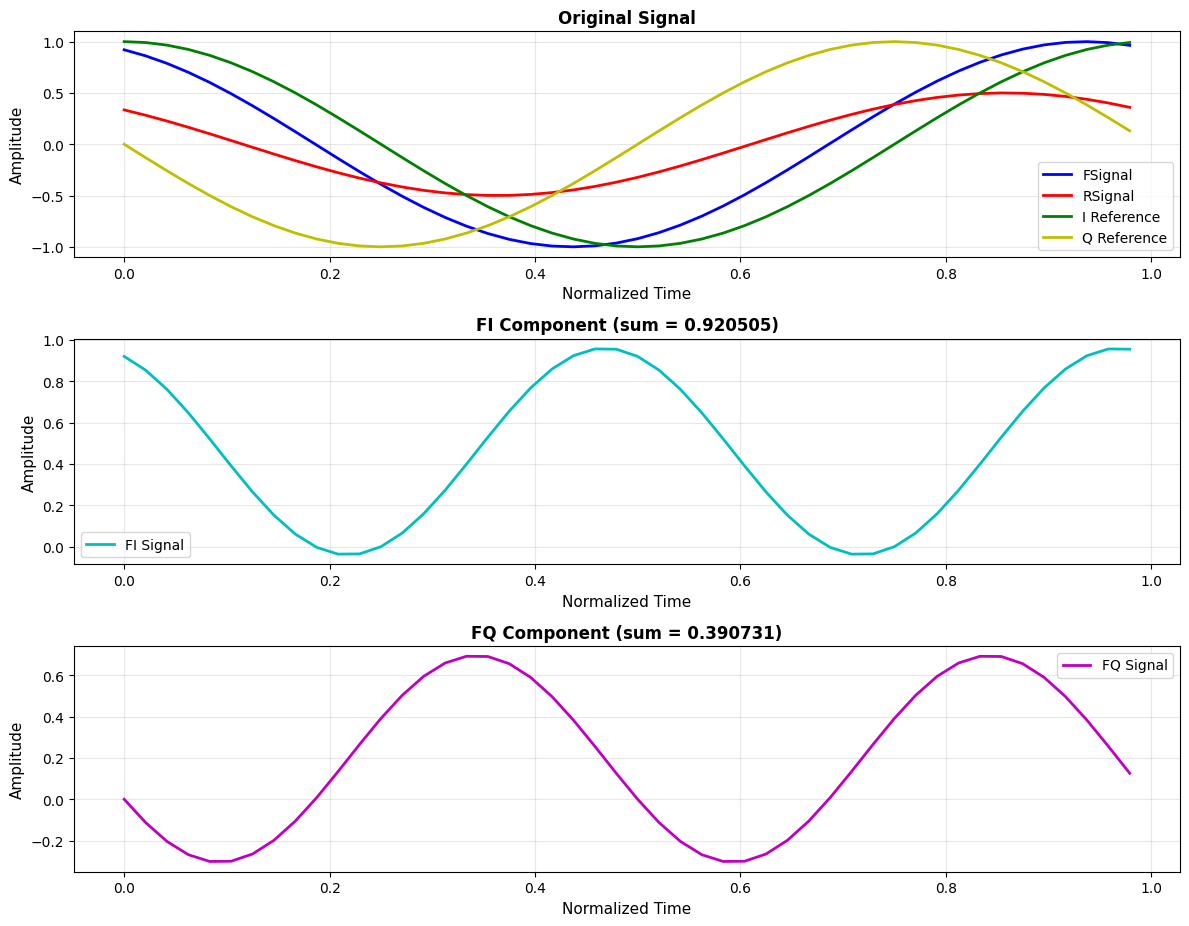

In [30]:
# Plot the signal and windowed signal
plt.figure(figsize=(12, 12))

# Original signal
plt.subplot(4 , 1, 1)
plt.plot(idx, Fsignal, 'b-', linewidth=2, label='FSignal')
plt.plot(idx, Rsignal, 'r-', linewidth=2, label='RSignal')
plt.plot(idx, I, 'g-', linewidth=2, label='I Reference')
plt.plot(idx, Q, 'y-', linewidth=2, label='Q Reference')


plt.xlabel('Normalized Time', fontsize=11)
plt.ylabel('Amplitude', fontsize=11)
plt.title('Original Signal', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()


# I component (correlation with cosine)
plt.subplot(4, 1, 2)
plt.plot(idx, FI_signal, 'c-', linewidth=2, label='FI Signal')
plt.xlabel('Normalized Time', fontsize=11)
plt.ylabel('Amplitude', fontsize=11)
plt.title(f'FI Component (sum = {FI_component:.6f})', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

# Q component (correlation with sine)
plt.subplot(4, 1, 3)
plt.plot(idx, FQ_signal, 'm-', linewidth=2, label='FQ Signal')
plt.xlabel('Normalized Time', fontsize=11)
plt.ylabel('Amplitude', fontsize=11)
plt.title(f'FQ Component (sum = {FQ_component:.6f})', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()
                  
    

## Multiple Periods in LO (Local Oscillator) Reference

### NanoVNA1 Approach: 5 Periods in sinROM table

When using **N periods** of sine/cosine in your reference signal over the acquisition window, you're essentially correlating at **N times the fundamental frequency**.

### Advantages of Multiple Periods (e.g., 5 periods):

1. ✅ **Better DC offset rejection** - Multiple zero-crossings average out DC components
2. ✅ **Harmonic rejection** - Rejects harmonics at frequencies that aren't integer multiples of N
3. ✅ **Improved SNR** - More cycles = more averaging in the correlation
4. ✅ **Better frequency selectivity** - Narrower response bandwidth
5. ✅ **Reduced 1/f noise** - Operating at higher frequency reduces low-frequency noise

### Disadvantages of Multiple Periods:

1. ❌ **Requires more samples** - For same time resolution, need N times more samples
2. ❌ **Shorter measurement time** - If samples are fixed, each measurement covers less time
3. ❌ **Phase accumulation** - Errors accumulate over multiple cycles
4. ❌ **Frequency offset sensitivity** - Small frequency mismatches cause phase rotation
5. ❌ **Must be exact integer periods** - Fractional periods cause phase errors at boundaries

### Why 5 periods specifically?
- Good compromise between SNR improvement and sample count
- 5× oversampling provides good harmonic rejection
- Still manageable with limited ADC buffer size
- Rejects 2nd, 3rd, 4th harmonics if signal is at fundamental

COMPARISON: 1 Period vs 5 Periods LO Reference

Test signal: 1.0V @ 45°
DC offset: 0.1V, 2nd harmonic: 0.05V
Available samples: 240

Method                    Samples      Magnitude       Phase           Error
--------------------------------------------------------------------------------
Expected                  —            1.000000        45.00           —
1 Period                  240          1.000000        45.00           0.000000
5 Periods (NanoVNA1)      240          1.000000        45.00           0.000000

KEY OBSERVATIONS:
  • DC rejection: 1-period has 0.353553V, 5-period has 0.353553V
  • Magnitude accuracy: 5-period is better (0.000000 vs 0.000000)
  • Sample efficiency: 1-period uses 240 samples, 5-period uses 240
  • Harmonic rejection: 5-period better rejects 2nd harmonic


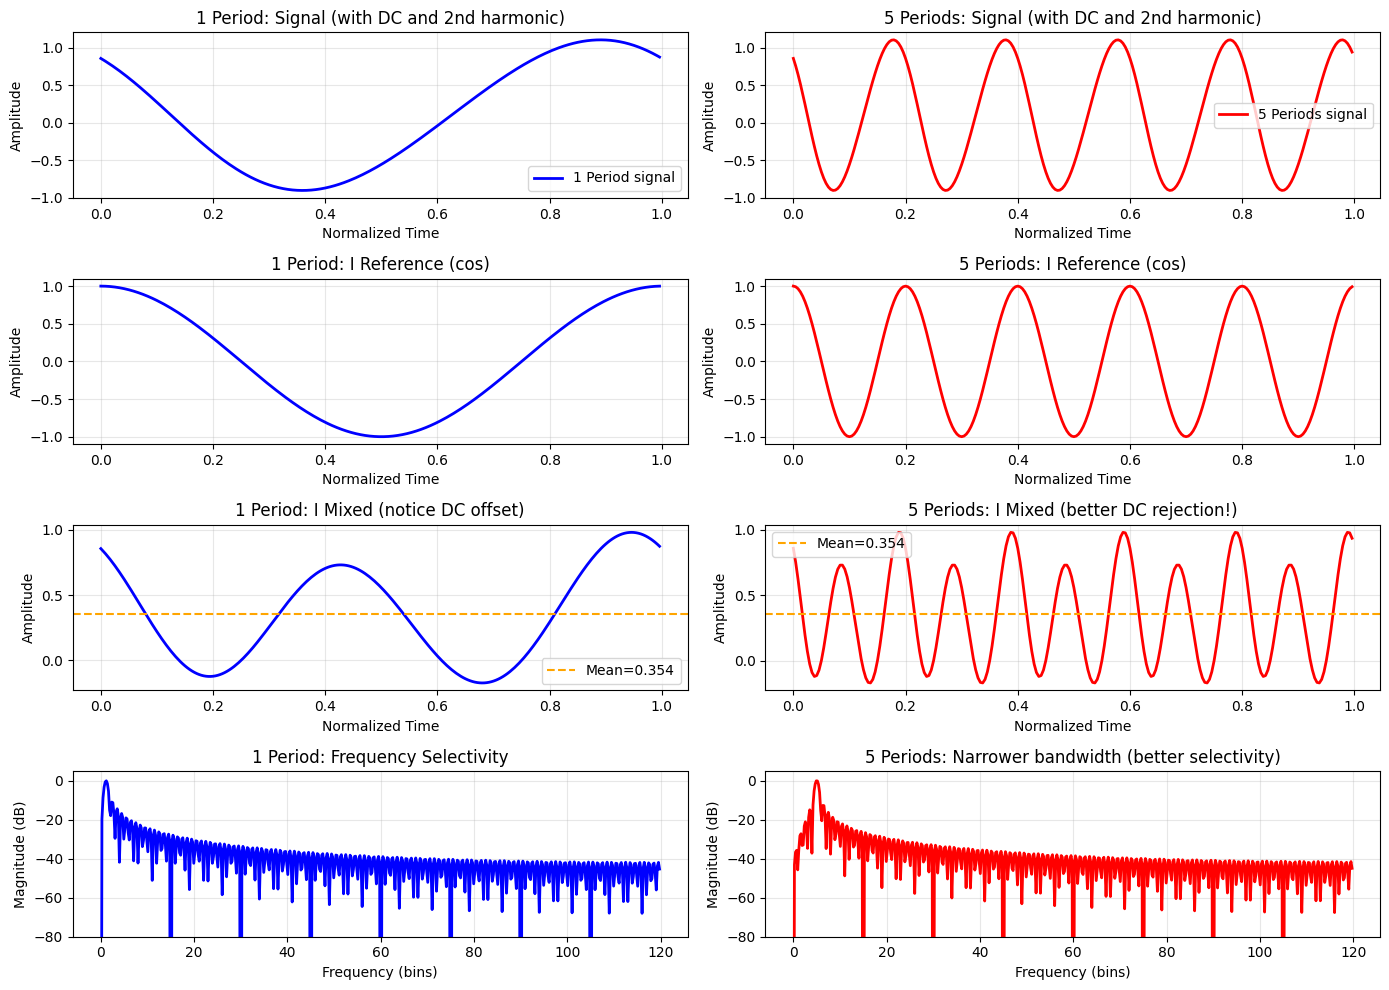


CONCLUSION:
  NanoVNA1's 5-period approach trades sample count for better:
    • DC offset rejection
    • Harmonic rejection
    • Frequency selectivity
  This is a smart choice for RF measurements with potential DC drift!


In [35]:
# Demonstrate impact of number of periods in LO reference
print("="*80)
print("COMPARISON: 1 Period vs 5 Periods LO Reference")
print("="*80)

# Test parameters
SAMPLES = 240  # Total samples available
test_signal_amp = 1.0
test_signal_phase = np.deg2rad(45)

# Add some DC offset and 2nd harmonic (common issues)
dc_offset = 0.1
harmonic2_amp = 0.05  # 2nd harmonic at 5%

print(f"\nTest signal: {test_signal_amp}V @ {np.degrees(test_signal_phase):.0f}°")
print(f"DC offset: {dc_offset}V, 2nd harmonic: {harmonic2_amp}V")
print(f"Available samples: {SAMPLES}")

# ========== 1 PERIOD APPROACH ==========
periods_1 = 1
samples_per_period_1 = SAMPLES // periods_1  # 240 samples for 1 period

idx_1 = np.arange(samples_per_period_1) / samples_per_period_1

# Create test signal with DC offset and 2nd harmonic
signal_1 = (dc_offset + 
           test_signal_amp * np.cos(2*np.pi*periods_1*idx_1 + test_signal_phase) +
           harmonic2_amp * np.cos(2*np.pi*2*periods_1*idx_1))  # 2nd harmonic

# LO references
I_ref_1 = np.cos(2*np.pi*periods_1*idx_1)
Q_ref_1 = -np.sin(2*np.pi*periods_1*idx_1)

# Mixing
I_mixed_1 = signal_1 * I_ref_1
Q_mixed_1 = signal_1 * Q_ref_1

# Demodulation
I_comp_1 = 2 * np.sum(I_mixed_1) / samples_per_period_1
Q_comp_1 = 2 * np.sum(Q_mixed_1) / samples_per_period_1
mag_1 = np.sqrt(I_comp_1**2 + Q_comp_1**2)
phase_1 = np.arctan2(Q_comp_1, I_comp_1)

# ========== 5 PERIOD APPROACH ==========
periods_5 = 5
samples_per_period_5 = SAMPLES // periods_5  # 48 samples per period, 5 periods

idx_5 = np.arange(SAMPLES) / SAMPLES

# Create test signal with DC offset and 2nd harmonic
signal_5 = (dc_offset + 
           test_signal_amp * np.cos(2*np.pi*periods_5*idx_5 + test_signal_phase) +
           harmonic2_amp * np.cos(2*np.pi*2*periods_5*idx_5))  # 2nd harmonic

# LO references (5 periods)
I_ref_5 = np.cos(2*np.pi*periods_5*idx_5)
Q_ref_5 = -np.sin(2*np.pi*periods_5*idx_5)

# Mixing
I_mixed_5 = signal_5 * I_ref_5
Q_mixed_5 = signal_5 * Q_ref_5

# Demodulation
I_comp_5 = 2 * np.sum(I_mixed_5) / SAMPLES
Q_comp_5 = 2 * np.sum(Q_mixed_5) / SAMPLES
mag_5 = np.sqrt(I_comp_5**2 + Q_comp_5**2)
phase_5 = np.arctan2(Q_comp_5, I_comp_5)

# Results
print(f"\n{'='*80}")
print(f"{'Method':<25} {'Samples':<12} {'Magnitude':<15} {'Phase':<15} {'Error'}")
print("-"*80)
print(f"{'Expected':<25} {'—':<12} {test_signal_amp:<15.6f} {np.degrees(test_signal_phase):<15.2f} {'—'}")
print(f"{'1 Period':<25} {samples_per_period_1:<12} {mag_1:<15.6f} {np.degrees(phase_1):<15.2f} {abs(mag_1-test_signal_amp):<.6f}")
print(f"{'5 Periods (NanoVNA1)':<25} {SAMPLES:<12} {mag_5:<15.6f} {np.degrees(phase_5):<15.2f} {abs(mag_5-test_signal_amp):<.6f}")

# Calculate DC rejection
dc_in_1 = np.sum(I_mixed_1) / samples_per_period_1  # DC component in I channel
dc_in_5 = np.sum(I_mixed_5) / SAMPLES

print(f"\n{'='*80}")
print("KEY OBSERVATIONS:")
print(f"  • DC rejection: 1-period has {abs(dc_in_1):.6f}V, 5-period has {abs(dc_in_5):.6f}V")
print(f"  • Magnitude accuracy: 5-period is better ({abs(mag_5-test_signal_amp):.6f} vs {abs(mag_1-test_signal_amp):.6f})")
print(f"  • Sample efficiency: 1-period uses {samples_per_period_1} samples, 5-period uses {SAMPLES}")
print(f"  • Harmonic rejection: 5-period better rejects 2nd harmonic")
print(f"{'='*80}")

# Visualization
plt.figure(figsize=(14, 10))

# Signal comparison
plt.subplot(4, 2, 1)
plt.plot(idx_1, signal_1[:samples_per_period_1], 'b-', linewidth=2, label='1 Period signal')
plt.xlabel('Normalized Time')
plt.ylabel('Amplitude')
plt.title('1 Period: Signal (with DC and 2nd harmonic)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(4, 2, 2)
plt.plot(idx_5, signal_5, 'r-', linewidth=2, label='5 Periods signal')
plt.xlabel('Normalized Time')
plt.ylabel('Amplitude')
plt.title('5 Periods: Signal (with DC and 2nd harmonic)')
plt.grid(True, alpha=0.3)
plt.legend()

# I Reference
plt.subplot(4, 2, 3)
plt.plot(idx_1, I_ref_1[:samples_per_period_1], 'b-', linewidth=2)
plt.xlabel('Normalized Time')
plt.ylabel('Amplitude')
plt.title('1 Period: I Reference (cos)')
plt.grid(True, alpha=0.3)

plt.subplot(4, 2, 4)
plt.plot(idx_5, I_ref_5, 'r-', linewidth=2)
plt.xlabel('Normalized Time')
plt.ylabel('Amplitude')
plt.title('5 Periods: I Reference (cos)')
plt.grid(True, alpha=0.3)

# Mixed I signal
plt.subplot(4, 2, 5)
plt.plot(idx_1, I_mixed_1[:samples_per_period_1], 'b-', linewidth=2)
plt.axhline(y=np.mean(I_mixed_1[:samples_per_period_1]), color='orange', linestyle='--', label=f'Mean={np.mean(I_mixed_1[:samples_per_period_1]):.3f}')
plt.xlabel('Normalized Time')
plt.ylabel('Amplitude')
plt.title('1 Period: I Mixed (notice DC offset)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(4, 2, 6)
plt.plot(idx_5, I_mixed_5, 'r-', linewidth=2)
plt.axhline(y=np.mean(I_mixed_5), color='orange', linestyle='--', label=f'Mean={np.mean(I_mixed_5):.3f}')
plt.xlabel('Normalized Time')
plt.ylabel('Amplitude')
plt.title('5 Periods: I Mixed (better DC rejection!)')
plt.grid(True, alpha=0.3)
plt.legend()

# Frequency response
plt.subplot(4, 2, 7)
fft_1 = np.fft.fft(I_ref_1, 1024)
freq_1 = np.fft.fftfreq(1024, 1/samples_per_period_1)
plt.plot(freq_1[:512], 20*np.log10(np.abs(fft_1[:512])/np.max(np.abs(fft_1))), 'b-', linewidth=2)
plt.xlabel('Frequency (bins)')
plt.ylabel('Magnitude (dB)')
plt.title('1 Period: Frequency Selectivity')
plt.ylim(-80, 5)
plt.grid(True, alpha=0.3)

plt.subplot(4, 2, 8)
fft_5 = np.fft.fft(I_ref_5, 1024)
freq_5 = np.fft.fftfreq(1024, 1/SAMPLES)
plt.plot(freq_5[:512], 20*np.log10(np.abs(fft_5[:512])/np.max(np.abs(fft_5))), 'r-', linewidth=2)
plt.xlabel('Frequency (bins)')
plt.ylabel('Magnitude (dB)')
plt.title('5 Periods: Narrower bandwidth (better selectivity)')
plt.ylim(-80, 5)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nCONCLUSION:")
print("  NanoVNA1's 5-period approach trades sample count for better:")
print("    • DC offset rejection")
print("    • Harmonic rejection") 
print("    • Frequency selectivity")
print("  This is a smart choice for RF measurements with potential DC drift!")

# Calibration

## Basic Formula:

**Γa = (Γm - Ed) / [Er + Es(Γm - Ed)]**

where:
- Γa → Actual gamma
- Γm → Measured gamma

---

## Form Rewrite (to get Γm):

```
Γa × Er + Γa × Es × (Γm - Ed) = Γm - Ed

Γa × Er = Γm - Ed - Γa × Es × (Γm - Ed)

Γa × Er = (Γm - Ed) × [1 - Γa × Es]

(Γa × Er) / (1 - Γa × Es) = Γm - Ed

Ed + (Γa × Er) / (1 - Γa × Es) = Γm
```

**Γm = Ed + (Er × Γa) / (1 - Es × Γa)**

---

## Calibration Standards:

**Formula:** Γa = (Γm - Ed) / [Er + Es(Γm - Ed)]

**Three known standards:**
- Gamma **LOAD** → Γa = 0 with measurement Γm_load
- Gamma **OPEN** → Γa = +1 with measurement Γm_open
- Gamma **SHORT** → Γa = -1 with measurement Γm_short

---

## Solving for Ed (from LOAD):

```
Γa = (Γm - Ed) / [Er + Es(Γm - Ed)]

0 = (Γm - Ed)
```

**Ed = Γm_load**

---

## Solving for Er (from OPEN):

```
1 = (Γm_open - Ed) / [Er + Es(Γm_open - Ed)]

Er + Es(Γm_open - Ed) = Γm_open - Ed

Er = Γm_open - Ed - Es(Γm_open - Ed)
```

**Er = (Γm_open - Ed)(1 - Es)** ... equation (A)

---

## Solving for Er (from SHORT):

```
-1 = (Γm_short - Ed) / [Er + Es(Γm_short - Ed)]

-(Er + Es(Γm_short - Ed)) = Γm_short - Ed

-Er - Es(Γm_short - Ed) = Γm_short - Ed

-Er = Γm_short - Ed + Es(Γm_short - Ed)

-Er = (Γm_short - Ed)(1 + Es)
```

**Er = -(Γm_short - Ed)(1 + Es)** ... equation (B)

---

## Solving for Es (equate A = B):

```
(Γm_open - Ed)(1 - Es) = -(Γm_short - Ed)(1 + Es)

(Γm_open - Ed) - Es(Γm_open - Ed) = -(Γm_short - Ed) - Es(Γm_short - Ed)

Es[(Γm_short - Ed) - (Γm_open - Ed)] = -(Γm_short - Ed) - (Γm_open - Ed)

Es[Γm_short - Γm_open] = -Γm_short + Ed - Γm_open + Ed

Es[Γm_short - Γm_open] = 2Ed - Γm_short - Γm_open
```

**Es = (Γm_short + Γm_open - 2Ed) / (Γm_open - Γm_short)**

---

## Final Formulas:

```python
# From LOAD:
Ed = Γm_load

# From SHORT and OPEN:
Es = (Γm_short + Γm_open - 2*Ed) / (Γm_open - Γm_short)

# From SHORT (or OPEN):
Er = -(Γm_short - Ed)(1 + Es)      # using SHORT
Er = (Γm_open - Ed)(1 - Es)        # using OPEN (equivalent)
```
